## ViT on MNIST

In [ ]:
!pip -q install torch torchvision matplotlib

In [ ]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(0)

## Patch Embedding

In [ ]:
class PatchEmbed(nn.Module):
    def __init__(self, img_size: int = 28, patch: int = 7, in_ch: int = 1, dim: int = 64):
        super().__init__()
        assert img_size % patch == 0
        self.proj = nn.Conv2d(in_ch, dim, kernel_size=patch, stride=patch)
        self.n_patches = (img_size // patch) ** 2
        self.cls = nn.Parameter(torch.zeros(1, 1, dim))
        self.pos = nn.Parameter(torch.zeros(1, self.n_patches + 1, dim))
        nn.init.trunc_normal_(self.pos, std=0.02)
        nn.init.trunc_normal_(self.cls, std=0.02)

    def forward(self, x):
        x = self.proj(x)
        x = x.flatten(2).transpose(1, 2)
        cls = self.cls.expand(x.size(0), -1, -1)
        x = torch.cat([x, cls], dim=1)
        x = x + self.pos
        return x

## Multi-Head Self-Attention

In [ ]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, dim: int, n_heads: int):
        super().__init__()
        assert dim % n_heads == 0
        self.n_heads = n_heads
        self.d_head = dim // n_heads
        self.qkv = nn.Linear(dim, 3 * dim)
        self.proj = nn.Linear(dim, dim)

    def forward(self, x):
        B, N, D = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.n_heads, self.d_head)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]

        scores = (q @ k.transpose(-2, -1)) / math.sqrt(self.d_head)
        attn = scores.softmax(dim=-1)
        out = attn @ v
        out = out.transpose(1, 2).reshape(B, N, D)
        return self.proj(out)

In [ ]:
class ViTBlock(nn.Module):
    def __init__(self, dim: int, n_heads: int, mlp_ratio: float = 4.0):
        super().__init__()
        self.ln1 = nn.LayerNorm(dim)
        self.attn = MultiHeadSelfAttention(dim, n_heads)
        self.ln2 = nn.LayerNorm(dim)
        hidden = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.GELU(),
            nn.Linear(hidden, dim),
        )

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x

## TinyViT Model

In [ ]:
class TinyViT(nn.Module):
    def __init__(
        self,
        img_size: int = 28,
        patch: int = 7,
        in_ch: int = 1,
        dim: int = 64,
        depth: int = 4,
        n_heads: int = 4,
        n_classes: int = 10,
    ):
        super().__init__()
        self.embed = PatchEmbed(img_size, patch, in_ch, dim)
        self.blocks = nn.ModuleList([ViTBlock(dim, n_heads) for _ in range(depth)])
        self.ln = nn.LayerNorm(dim)
        self.head = nn.Linear(dim, n_classes)

    def forward(self, x):
        x = self.embed(x)
        for blk in self.blocks:
            x = blk(x)
        x = self.ln(x)
        cls = x[:, -1]
        return self.head(cls)

model = TinyViT().to(DEVICE)

## Training

In [ ]:
tfm = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
train_ds = datasets.MNIST(root="./data", train=True,  download=True, transform=tfm)
test_ds  = datasets.MNIST(root="./data", train=False, download=True, transform=tfm)
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False, num_workers=2)

opt = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.05)
EPOCHS = 3
for epoch in range(EPOCHS):
    model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        logits = model(xb)
        loss = F.cross_entropy(logits, yb)
        opt.zero_grad()
        loss.backward()
        opt.step()

    model.eval()
    correct = total = 0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            pred = model(xb).argmax(-1)
            correct += (pred == yb).sum().item()
            total   += yb.numel()
    print(f"epoch {epoch+1}: test acc = {correct/total:.4f}")

epoch 1: test acc = 0.8801
epoch 2: test acc = 0.9299
epoch 3: test acc = 0.9416


## Predictions

Original label: 8
Input image shape: torch.Size([1, 1, 28, 28])
Predicted class: 8


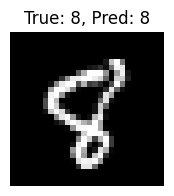

In [ ]:
model.eval()

random_idx = torch.randint(0, len(test_ds), (1,)).item()
sample_image, sample_label = test_ds[random_idx]

input_image = sample_image.unsqueeze(0).to(DEVICE)

print(f"Original label: {sample_label}")
print(f"Input image shape: {input_image.shape}")

with torch.no_grad():
    output_logits = model(input_image);
    predicted_class = output_logits.argmax(dim=-1).item()

print(f"Predicted class: {predicted_class}")

plt.figure(figsize=(2, 2))
plt.imshow(sample_image.squeeze().cpu(), cmap="gray")
plt.title(f"True: {sample_label}, Pred: {predicted_class}")
plt.axis("off")
plt.show()